### Prediccion

### Importar librerias

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score
from sklearn.feature_selection import mutual_info_classif

### Leer csv

In [28]:
df = pd.read_csv("data.csv")
df.head()

,fecha,latitud,longitud,alcaldia,colonia,temp,precip,humedad,viento,radiacion,presion,incidente
0,2019-01-03,19.384348,-99.191522,ALVARO OBREGON,SANTA MARIA NONOALCO,12.14,0.0,52.31,0.7,4.4076,74.5,Inundacion
1,2019-01-03,19.384560,-99.190621,BENITO JUAREZ,NONOALCO,12.14,0.0,52.31,0.7,4.4076,74.5,Encharcamiento
2,2019-01-03,19.384560,-99.190621,BENITO JUAREZ,NONOALCO,12.14,0.0,52.31,0.7,4.4076,74.5,Inundacion
3,2019-01-03,19.384560,-99.190621,BENITO JUAREZ,NONOALCO,12.14,0.0,52.31,0.7,4.4076,74.5,Encharcamiento
4,2019-01-03,19.384560,-99.190621,BENITO JUAREZ,NONOALCO,12.14,0.0,52.31,0.7,4.4076,74.5,Inundacion


In [20]:
df.shape[0]

25500

In [52]:
Y = df["incidente"]
X = df.drop(columns =["incidente","alcaldia","colonia","fecha"])

In [53]:
Y.head()

0        Inundacion
1    Encharcamiento
2        Inundacion
3    Encharcamiento
4        Inundacion
Name: incidente, dtype: object

In [54]:
X.head()

,latitud,longitud,temp,precip,humedad,viento,radiacion,presion
0,19.384348,-99.191522,12.14,0.0,52.31,0.7,4.4076,74.5
1,19.384560,-99.190621,12.14,0.0,52.31,0.7,4.4076,74.5
2,19.384560,-99.190621,12.14,0.0,52.31,0.7,4.4076,74.5
3,19.384560,-99.190621,12.14,0.0,52.31,0.7,4.4076,74.5
4,19.384560,-99.190621,12.14,0.0,52.31,0.7,4.4076,74.5


In [55]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y)

In [56]:
X_train.shape[1]

8

### Explorar variables

#### Temperatura

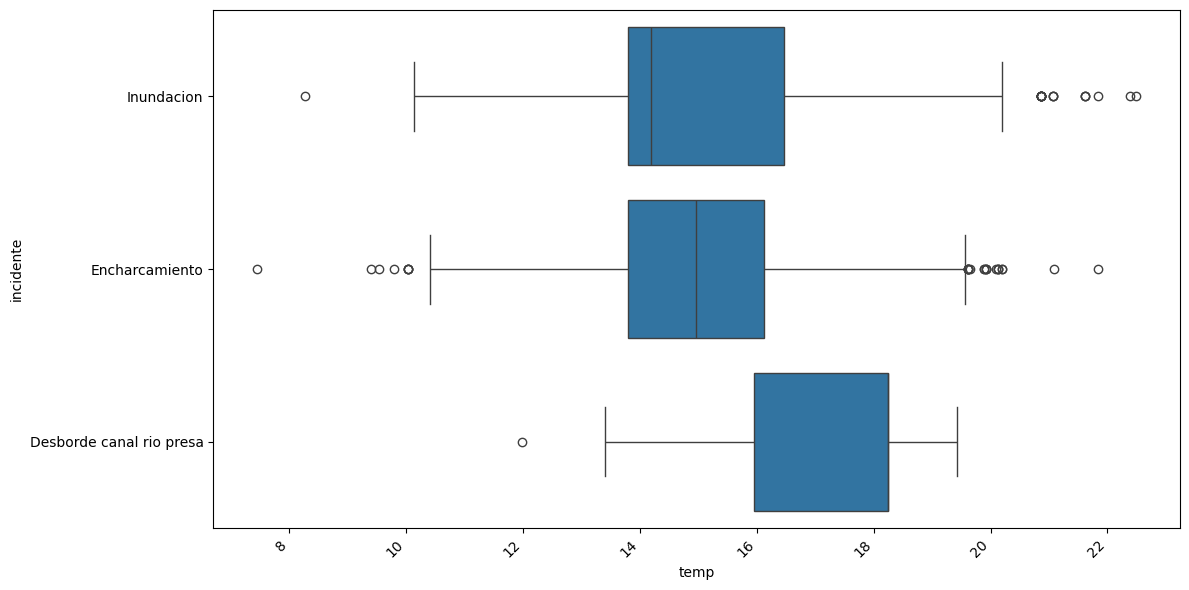

In [57]:
plt.figure(figsize=(12, 6))
sns.boxplot(x = X["temp"], y= Y, data=df)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Precipitacion

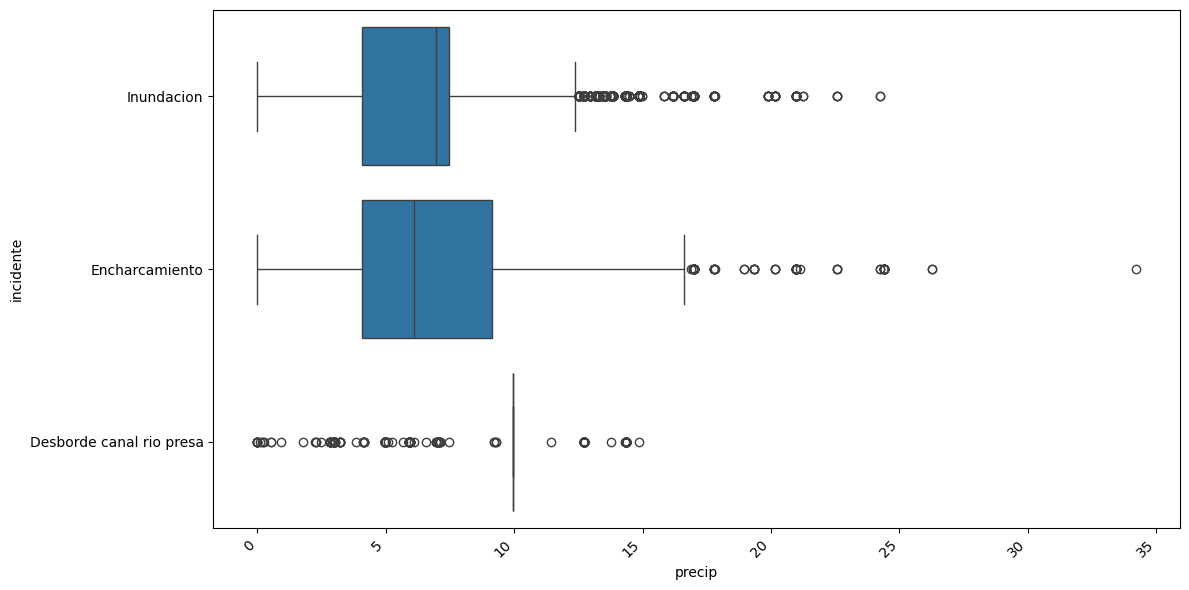

In [58]:
plt.figure(figsize=(12, 6))
sns.boxplot(x = X["precip"], y= Y, data=df)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Humedad

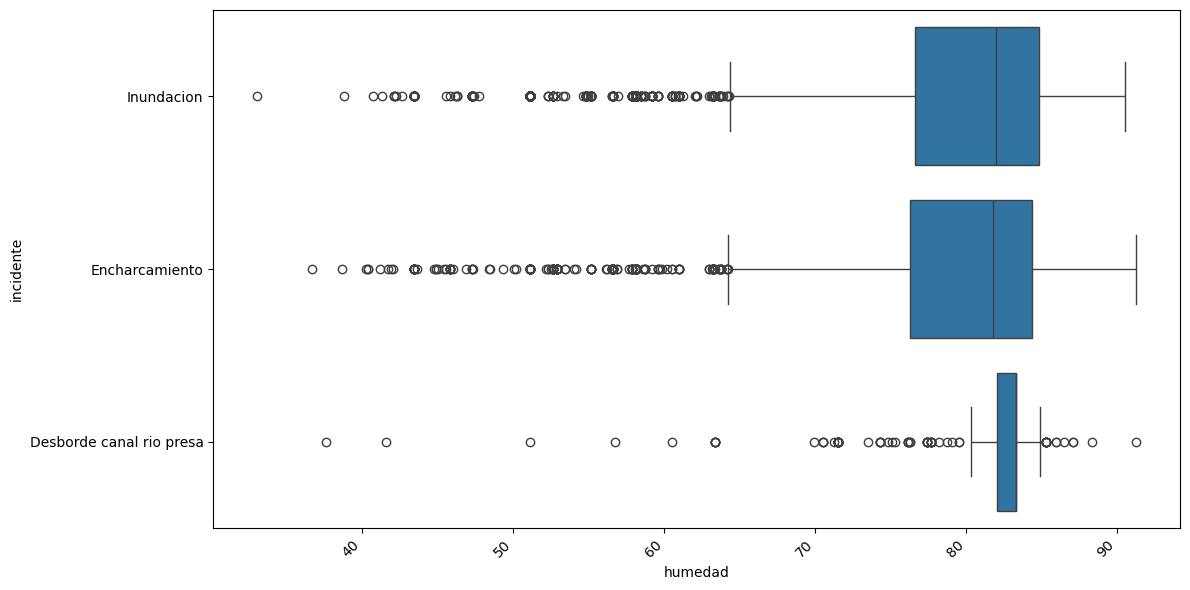

In [59]:
plt.figure(figsize=(12, 6))
sns.boxplot(x = X["humedad"], y= Y, data=df)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Viento

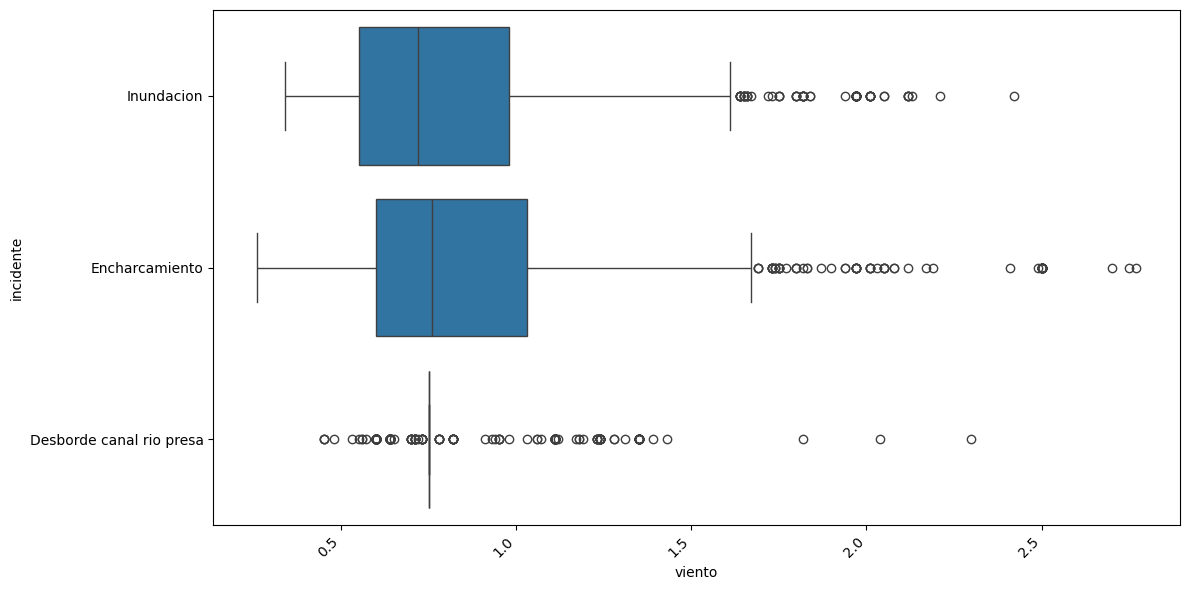

In [60]:
plt.figure(figsize=(12, 6))
sns.boxplot(x = X["viento"], y= Y, data=df)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### radiacion

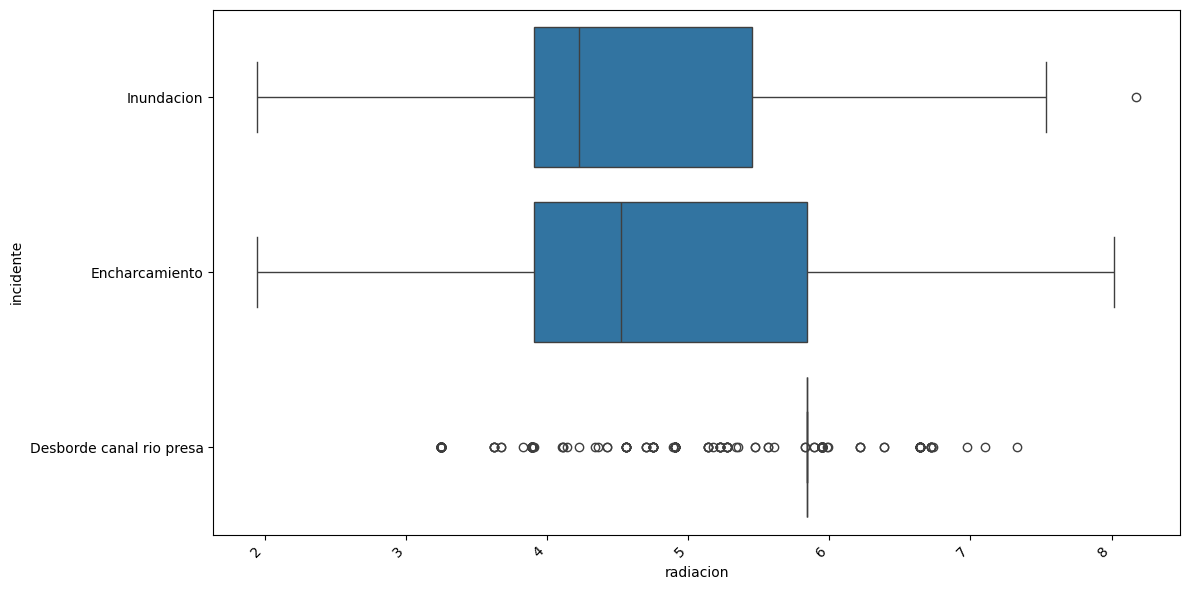

In [61]:
plt.figure(figsize=(12, 6))
sns.boxplot(x = X["radiacion"], y= Y, data=df)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### presion

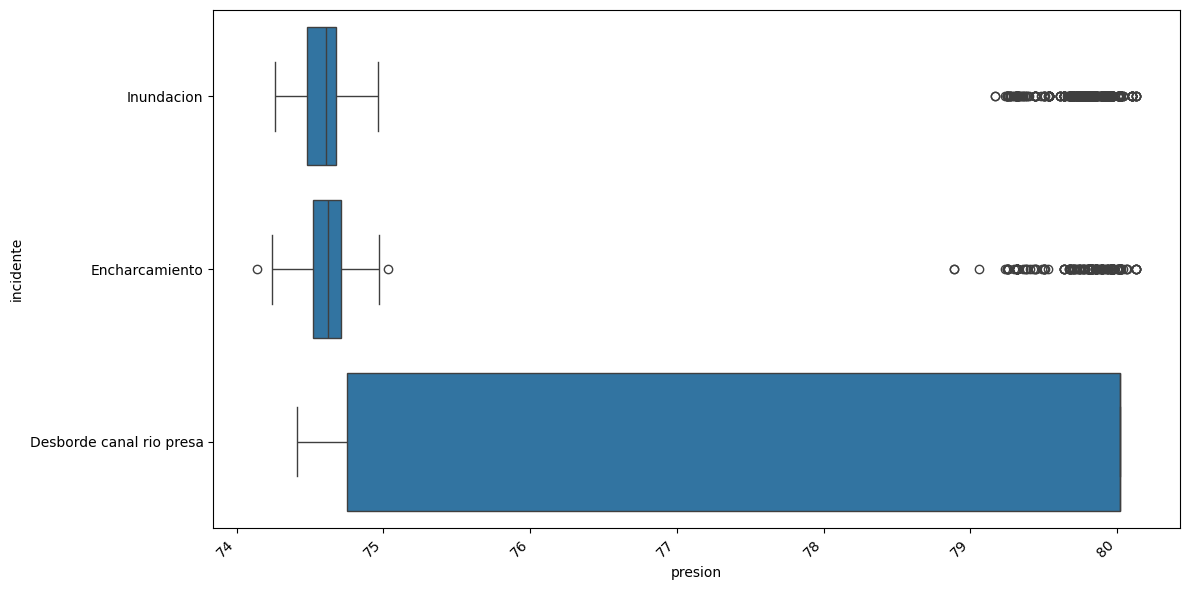

In [62]:
plt.figure(figsize=(12, 6))
sns.boxplot(x = X["presion"], y= Y, data=df)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### latitud

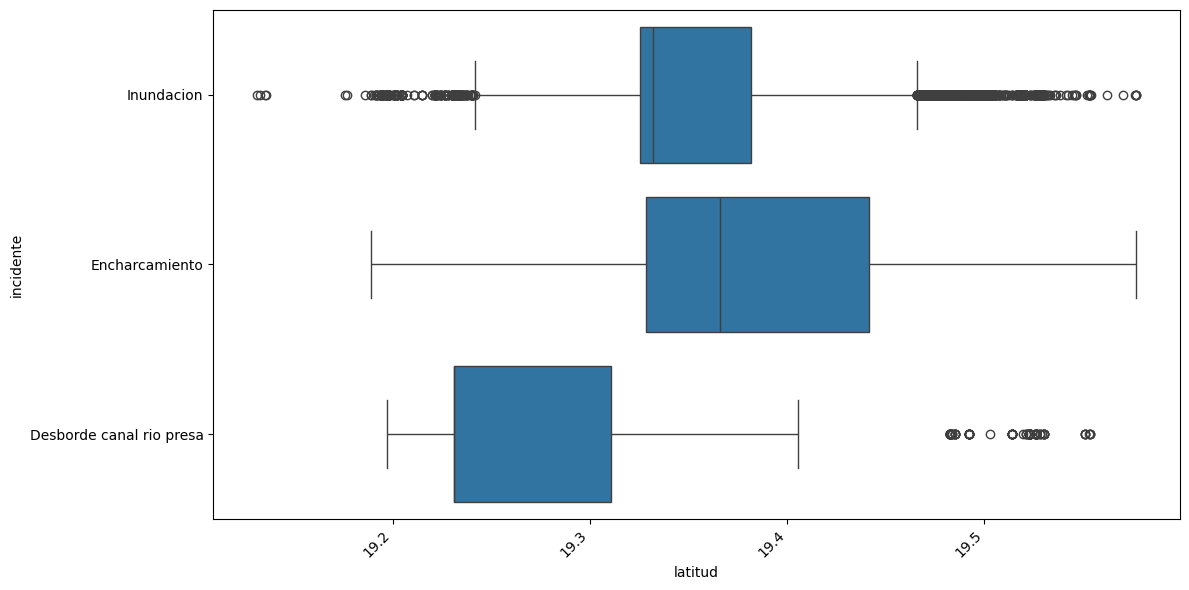

In [63]:
plt.figure(figsize=(12, 6))
sns.boxplot(x = X["latitud"], y= Y, data=df)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### longitud

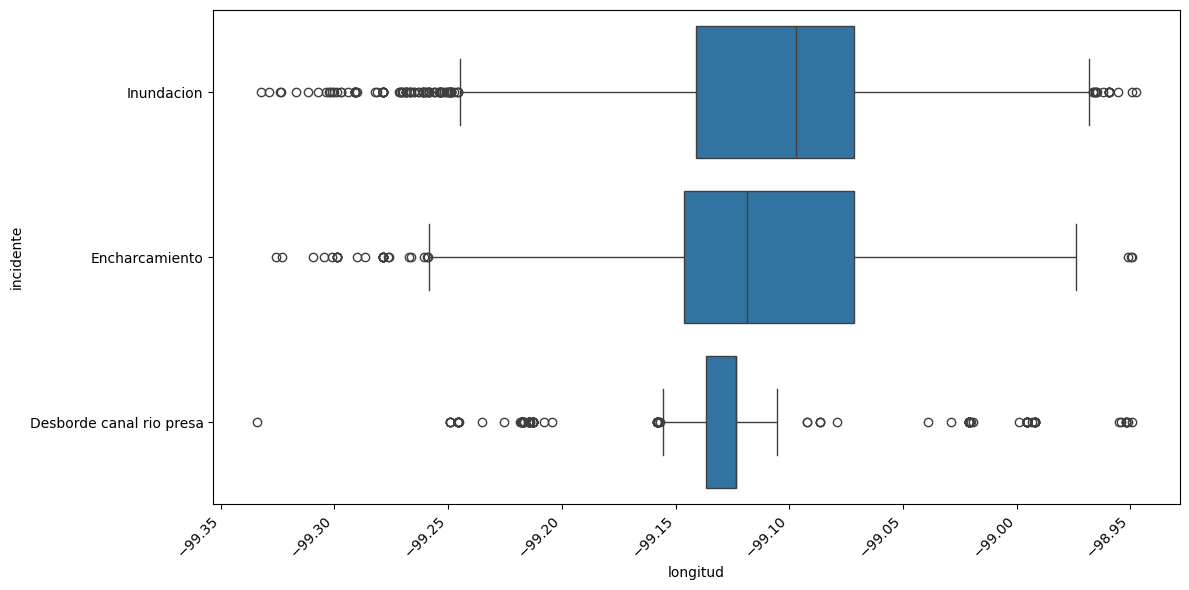

In [64]:
plt.figure(figsize=(12, 6))
sns.boxplot(x = X["longitud"], y= Y, data=df)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [68]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    
    # Entrenar
    model.fit(X_train, Y_train)
    
    # Predecir
    y_pred = model.predict(X_test)
    
    # Métricas
    acc = accuracy_score(Y_test, y_pred)
    prec = precision_score(Y_test, y_pred, average="macro")
    
    results[name] = {
        "accuracy": acc,
        "precision": prec
    }

# Mostrar resultados
for name, metrics in results.items():
    print(f"\n{name}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")

C:\Users\luigu\anaconda3\envs\luis\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
Accuracy: 0.8039
Precision: 0.7174

KNN
Accuracy: 0.8359
Precision: 0.7104

Random Forest
Accuracy: 0.8436
Precision: 0.7438
